In [34]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from datetime import datetime

In [35]:
def get_timestamp():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

In [36]:
# Ruta del archivo
current_path = os.getcwd()
data_src_path = os.path.join(current_path, "data_src")
data_dst_path = os.path.join(current_path, "data_dst")
file_name = "articulos_revisados.xlsx"
file_path = os.path.join(data_src_path, file_name)

In [37]:
file_path

'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_src\\articulos_revisados.xlsx'

In [38]:
# Verificar que el archivo existe
if os.path.exists(file_path):
    # Cargar CSV
    df = pd.read_excel(file_path) #!pip install openpyxl
    print("Archivo cargado correctamente. Primeras filas:")
    # print(df.head())
else:
    print(f"Archivo no encontrado en {file_path}")

Archivo cargado correctamente. Primeras filas:


In [39]:
df.head()

,DOI,Title,Abstract,TAGs,XR,GAME,ASD,AI,CAT_Biomarker
0,10.4018/979-8-3693-8985-0.ch011,Current advancements in AI-driven education,"With the rise of Artificial Intelligence (AI),...","VR, AR, AI, GAME, ASD","VR, AR",1,1,1,tracking
1,10.1089/g4h.2023.0240,The Impact of Virtual Reality Intervention on ...,Introduction: Autistic children may encounter ...,"VR, ASD, GAME",VR,1,1,0,NaN
2,10.1007/s10758-024-09806-6,Game-Based Performance Tasks for Assessing Rep...,"In this exploratory study, we designed and val...","VR, ASD, GAME",VR,1,1,0,"tracking, neuro"
3,10.1002/jdn.70000,Virtual Reality-Based Attention Prediction Mod...,"Nowadays, virtual reality (VR) has emerged as ...","VR, ASD, GAME",VR,1,1,0,"eye, neuro"
4,10.4018/979-8-3693-7437-5.ch009,The impact of a gamified augmented environment...,This study investigates the impact of a Gamifi...,"AR, ASD, GAME",AR,1,1,0,NaN


In [40]:
df_backup = df.copy()

In [41]:
def assert_valid_xr_game_asd(df):
    """
    Comprueba que:
    - GAME == 1 en todas las filas
    - ASD == 1 en todas las filas
    - XR no está vacío ni es NaN
    """

    assert (df["GAME"] == 1).all(), "ERROR: No todas las filas tienen GAME == 1"
    assert (df["ASD"] == 1).all(), "ERROR: No todas las filas tienen ASD == 1"
    assert df["XR"].notna().all(), "ERROR: Hay valores NaN en XR"
    assert (df["XR"].astype(str).str.strip() != "").all(), "ERROR: Hay valores vacíos en XR"

    print("[OK] Validación superada: GAME=1, ASD=1 y XR no vacío.")

In [42]:
assert_valid_xr_game_asd(df)

[OK] Validación superada: GAME=1, ASD=1 y XR no vacío.


In [43]:
def save_and_show_plot(fig, data_dst_path, filename_base):
    os.makedirs(data_dst_path, exist_ok=True)

    timestamp = get_timestamp()

    png_path = os.path.join(data_dst_path, f"{filename_base}_{timestamp}.png")
    pdf_path = os.path.join(data_dst_path, f"{filename_base}_{timestamp}.pdf")

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return png_path, pdf_path

In [54]:
def _split_multilabel_values(series, sep=","):
    return (
        series
        .fillna("")
        .astype(str)
        .apply(lambda x: [v.strip() for v in x.split(sep) if v.strip() != ""])
    )


def _get_multilabel_counts(df, col, sep=","):
    values = _split_multilabel_values(df[col], sep=sep)
    unique_values = sorted(set(v for row in values for v in row))

    counts = {
        value: values.apply(lambda row: value in row).sum()
        for value in unique_values
    }

    return pd.Series(counts).sort_values(ascending=False)


def plot_bar_column(df, col, data_dst_path, filename_base=None, sep=",", rotate_labels=False):
    """
    Barplot para columnas multietiqueta.
    Si una fila tiene 'VR, AR', cuenta 1 para VR y 1 para AR.
    """

    if filename_base is None:
        filename_base = f"barplot_{col}"

    counts = _get_multilabel_counts(df, col, sep=sep)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(counts.index.astype(str), counts.values)

    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.set_title(f"{col} distribution")
    ax.grid(axis="y", alpha=0.3)

    if rotate_labels:
        ax.tick_params(axis="x", labelrotation=45)
        for label in ax.get_xticklabels():
            label.set_ha("right")

    return save_and_show_plot(fig, data_dst_path, filename_base)


def plot_bubble_categorical(df, x_col, y_col, data_dst_path, filename_base=None, sep=","):
    """
    Bubbleplot para columnas multietiqueta.
    Si XR='VR, AR' y Biomarker='tracking, neuro',
    cuenta todas las combinaciones:
    VR-tracking, VR-neuro, AR-tracking, AR-neuro.
    """

    if filename_base is None:
        filename_base = f"bubble_{x_col}_vs_{y_col}"

    rows = []

    x_values = _split_multilabel_values(df[x_col], sep=sep)
    y_values = _split_multilabel_values(df[y_col], sep=sep)

    for x_list, y_list in zip(x_values, y_values):
        for x in x_list:
            for y in y_list:
                rows.append((x, y))

    if len(rows) == 0:
        raise ValueError(f"No hay combinaciones válidas entre {x_col} y {y_col}.")

    df_pairs = pd.DataFrame(rows, columns=[x_col, y_col])

    counts = (
        df_pairs.groupby([x_col, y_col])
        .size()
        .reset_index(name="count")
    )

    x_unique = sorted(df_pairs[x_col].unique())
    y_unique = sorted(df_pairs[y_col].unique())

    x_map = {v: i for i, v in enumerate(x_unique)}
    y_map = {v: i for i, v in enumerate(y_unique)}

    counts["x_pos"] = counts[x_col].map(x_map)
    counts["y_pos"] = counts[y_col].map(y_map)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(
        counts["x_pos"],
        counts["y_pos"],
        s=counts["count"] * 120,
        alpha=0.6
    )

    for _, row in counts.iterrows():
        ax.text(
            row["x_pos"],
            row["y_pos"],
            str(row["count"]),
            ha="center",
            va="center",
            fontsize=9
        )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}")

    ax.set_xticks(list(x_map.values()))
    ax.set_xticklabels(list(x_map.keys()), rotation=45, ha="right")

    ax.set_yticks(list(y_map.values()))
    ax.set_yticklabels(list(y_map.keys()))

    ax.grid(alpha=0.3)

    return save_and_show_plot(fig, data_dst_path, filename_base)


def plot_bar_xr(df, data_dst_path):
    return plot_bar_column(
        df=df,
        col="XR",
        data_dst_path=data_dst_path,
        filename_base="barplot_XR",
        sep=",",
        rotate_labels=False
    )


def plot_bar_biomarkers(df, data_dst_path):
    return plot_bar_column(
        df=df,
        col="Biomarker",
        data_dst_path=data_dst_path,
        filename_base="barplot_Biomarker",
        sep=",",
        rotate_labels=True
    )


def plot_bubble_xr_biomarkers(df, data_dst_path):
    return plot_bubble_categorical(
        df=df,
        x_col="XR",
        y_col="Biomarker",
        data_dst_path=data_dst_path,
        filename_base="bubble_XR_vs_Biomarker",
        sep=","
    )


def plot_bubble_xr_ai(df, data_dst_path):
    return plot_bubble_categorical(
        df=df,
        x_col="XR",
        y_col="AI",
        data_dst_path=data_dst_path,
        filename_base="bubble_XR_vs_AI",
        sep=","
    )


def plot_bubble_biomarkers_ai(df, data_dst_path):
    return plot_bubble_categorical(
        df=df,
        x_col="AI",
        y_col="Biomarker",
        data_dst_path=data_dst_path,
        filename_base="bubble_AI_vs_Biomarker",
        sep=","
    )

In [45]:
def expand_multilabel_column(df, col, prefix=None, sep=","):
    """
    Convierte una columna multietiqueta en columnas binarias.

    Ejemplo:
    XR = "VR, AR"

    genera:
    XR_VR = 1
    XR_AR = 1
    """

    df = df.copy()

    if prefix is None:
        prefix = col

    values = (
        df[col]
        .fillna("")
        .astype(str)
        .apply(lambda x: [v.strip() for v in x.split(sep) if v.strip() != ""])
    )

    unique_values = sorted(set(v for row in values for v in row))

    for value in unique_values:
        df[f"{prefix}_{value}"] = values.apply(lambda row: int(value in row))

    return df, unique_values

In [46]:
if "CAT_Biomarker" in df.columns:
        df = df.rename(columns={"CAT_Biomarker": "Biomarker"})

In [47]:
df, xr_values = expand_multilabel_column(df, col="XR", prefix="XR")
df, biomarker_values = expand_multilabel_column(df, col="Biomarker", prefix="Biomarker")

In [48]:
def plot_bar_multilabel(df, columns, label_prefix, data_dst_path, filename_base):
    """
    Barplot donde cada barra cuenta cuántas filas tienen esa categoría,
    aunque aparezca combinada con otras.
    """

    counts = df[columns].sum().sort_values(ascending=False)

    clean_labels = [c.replace(f"{label_prefix}_", "") for c in counts.index]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(clean_labels, counts.values)

    ax.set_xlabel(label_prefix)
    ax.set_ylabel("Count")
    ax.set_title(f"{label_prefix} distribution")
    ax.grid(axis="y", alpha=0.3)

    return save_and_show_plot(fig, data_dst_path, filename_base)

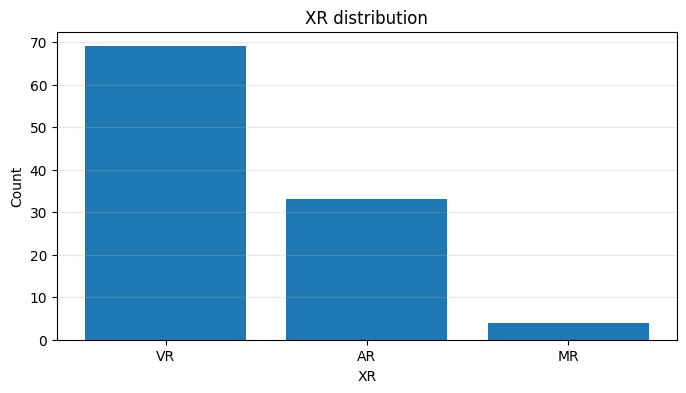

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\barplot_XR_20260601_124937.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\barplot_XR_20260601_124937.pdf')

In [56]:
plot_bar_xr(df, data_dst_path)

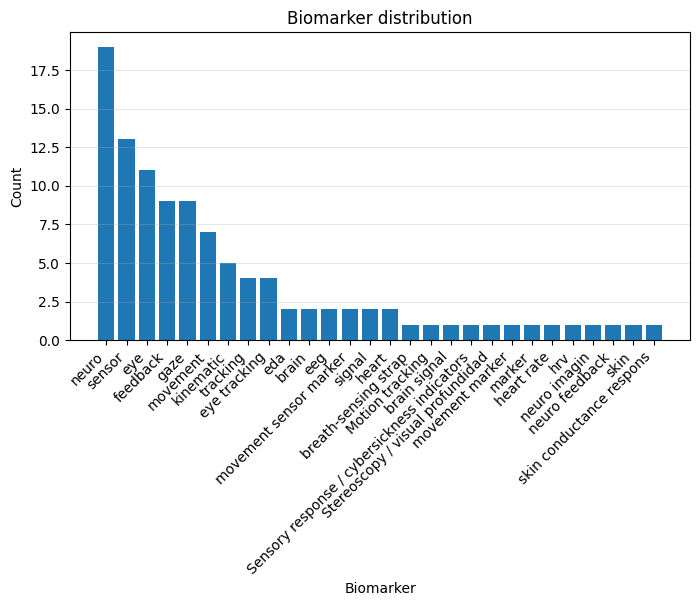

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\barplot_Biomarker_20260601_124939.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\barplot_Biomarker_20260601_124939.pdf')

In [57]:
plot_bar_biomarkers(df, data_dst_path)

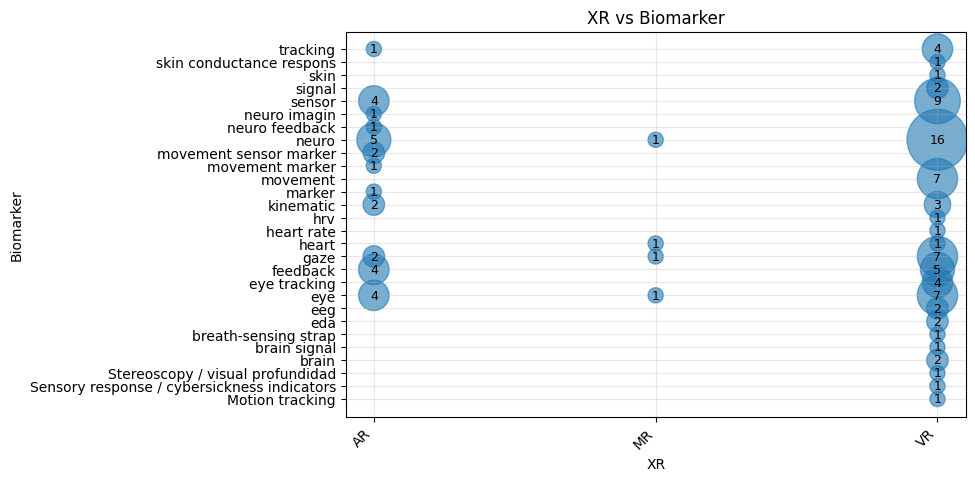

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_XR_vs_Biomarker_20260601_124941.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_XR_vs_Biomarker_20260601_124941.pdf')

In [58]:
plot_bubble_xr_biomarkers(df, data_dst_path)

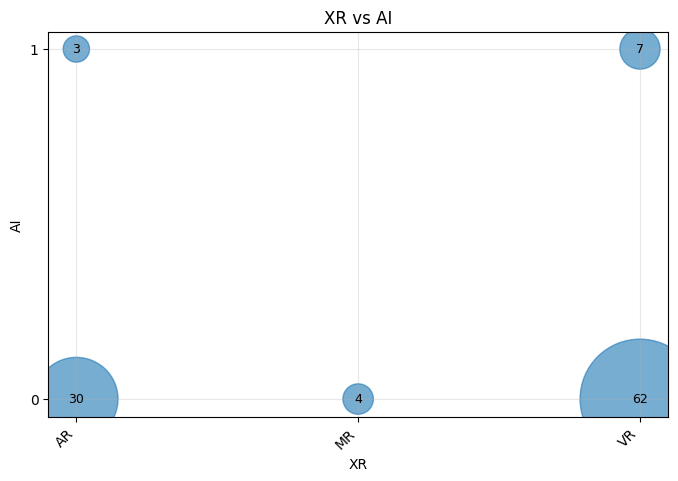

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_XR_vs_AI_20260601_124945.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_XR_vs_AI_20260601_124945.pdf')

In [59]:
plot_bubble_xr_ai(df, data_dst_path)

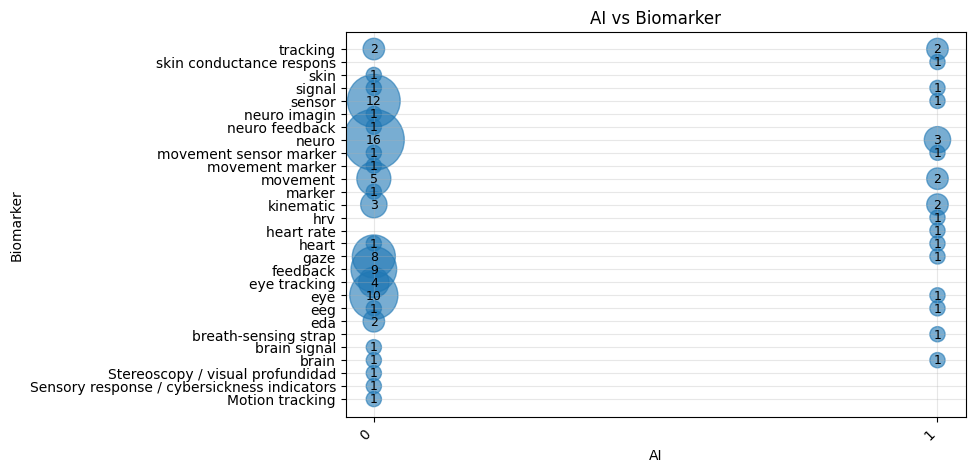

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_AI_vs_Biomarker_20260601_124925.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_AI_vs_Biomarker_20260601_124925.pdf')

In [55]:
plot_bubble_biomarkers_ai(df, data_dst_path)